In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

import pandas as pd

from loaders.measurement import Measurement
from scipy.stats import bootstrap


mpl.rcParams['figure.dpi'] = 175
sns.set_context('paper')
sns.set_palette(sns.color_palette("tab10"))

custom_font_size=8
mpl.rcParams.update({
    'font.size': custom_font_size,
    'axes.labelsize': custom_font_size,
    'axes.titlesize': custom_font_size,
    'legend.title_fontsize': custom_font_size,
    'legend.fontsize': custom_font_size,
    'xtick.labelsize': custom_font_size,
    'ytick.labelsize': custom_font_size,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'xtick.top':          False,
    'xtick.bottom':       True,
    'ytick.left':         True,
    'ytick.right':        False,
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
})

acm_column_width = 3.3374
pd.options.display.max_colwidth = 100

In [ ]:

paths = ["../data/teams/de-terrestrial", "../data/teams/nl-terrestrial"]


folders = []

for path in paths:
    for folder in [f.path for f in os.scandir(path) if f.is_dir()]:
        folders.append(folder)

measurements_teams_terrestrial = dict()
for folder in folders:
    sender_parquet = os.path.join(folder, "sender.parquet")
    receiver_parquet = os.path.join(folder, "receiver.parquet")
    if not (os.path.exists(sender_parquet) and os.path.exists(receiver_parquet)):
        print(f"Skipping {folder}: missing sender.parquet or receiver.parquet")
        continue
    try:
        measurement = Measurement(folder)
        measurement.load_files()
        measurements_teams_terrestrial[folder] = measurement
    except Exception as e:
        print(f"Warning: {e}")




Loading IRTT data from file: ../data/teams/de-terrestrial/video-Teams-1777033929/irtt-sender.json
Loading Parquet data from file: ../data/teams/de-terrestrial/video-Teams-1777033929/sender.parquet
Loading Parquet data from file: ../data/teams/de-terrestrial/video-Teams-1777033929/receiver.parquet
Loading IRTT data from file: ../data/teams/de-terrestrial/video-Teams-1777069934/irtt-sender.json
Loading Parquet data from file: ../data/teams/de-terrestrial/video-Teams-1777069934/sender.parquet
Loading Parquet data from file: ../data/teams/de-terrestrial/video-Teams-1777069934/receiver.parquet
Loading IRTT data from file: ../data/teams/de-terrestrial/video-Teams-1777062728/irtt-sender.json
Loading Parquet data from file: ../data/teams/de-terrestrial/video-Teams-1777062728/sender.parquet
Loading Parquet data from file: ../data/teams/de-terrestrial/video-Teams-1777062728/receiver.parquet
Loading IRTT data from file: ../data/teams/de-terrestrial/video-Teams-1777012329/irtt-sender.json
Loading 

In [ ]:

paths = ["../data/teams/aq-starlink", "../data/teams/no-starlink", "../data/teams/de-starlink", "../data/teams/nl-starlink"]


folders = []

for path in paths:
    for folder in [f.path for f in os.scandir(path) if f.is_dir()]:
        folders.append(folder)

measurements_teams = dict()
for folder in folders:
    sender_parquet = os.path.join(folder, "sender.parquet")
    receiver_parquet = os.path.join(folder, "receiver.parquet")
    if not (os.path.exists(sender_parquet) and os.path.exists(receiver_parquet)):
        print(f"Skipping {folder}: missing sender.parquet or receiver.parquet")
        continue
    try:
        measurement = Measurement(folder)
        measurement.load_files()
        measurements_teams[folder] = measurement
    except Exception as e:
        print(f"Warning: {e}")




Loading Dishy data from file: ../data/teams/aq-starlink/video-Teams-1764813613/dishy_sender.json
Loading Parquet data from file: ../data/teams/aq-starlink/video-Teams-1764813613/sender.parquet
Loading Parquet data from file: ../data/teams/aq-starlink/video-Teams-1764813613/receiver.parquet
Loading Dishy data from file: ../data/teams/aq-starlink/video-Teams-1764943212/dishy_sender.json
Loading Parquet data from file: ../data/teams/aq-starlink/video-Teams-1764943212/sender.parquet
Loading Parquet data from file: ../data/teams/aq-starlink/video-Teams-1764943212/receiver.parquet
Loading Dishy data from file: ../data/teams/aq-starlink/video-Teams-1764936011/dishy_sender.json
Loading Parquet data from file: ../data/teams/aq-starlink/video-Teams-1764936011/sender.parquet
Loading Parquet data from file: ../data/teams/aq-starlink/video-Teams-1764936011/receiver.parquet
Loading Dishy data from file: ../data/teams/aq-starlink/video-Teams-1764856812/dishy_sender.json
Loading Parquet data from file

In [ ]:

def gather_sent_bitrate_samples_trimmed(measurement, resample_ms, trim_start = 30.0, trim_end = 0.0):
    if measurement.data_parquet_sender is None:
        raise ValueError("missing sender parquet data")
    if "OutboundRTP.BytesSent" not in measurement.data_parquet_sender.data:
        return None
    send_vals = measurement.data_parquet_sender.data["OutboundRTP.BytesSent"].resample(f"{resample_ms}ms").max().diff().fillna(0).clip(lower=0)
    send_vals = (send_vals / 1000) * 8 * (1000/resample_ms)
    send_vals.index.name = 'Timestamp'
    send_vals.name = "send_kbps"
    if send_vals is None or send_vals.empty:
        return []
    trim_start_ = pd.Timedelta(seconds=trim_start)
    trim_end_ = pd.Timedelta(seconds=trim_end)
    send_vals = send_vals.loc[send_vals.index.min() + trim_start_ : send_vals.index.max() - trim_end_]
    bitrate_values_mbps = (send_vals.to_numpy() * 0.001).tolist()
    return [v for v in bitrate_values_mbps if np.isfinite(v) and v >= 0]

In [ ]:
def gather_send_fps_samples_trimmed(measurement, trim_start = 30.0, trim_end = 0.0):
    if "OutboundRTP.FramesSent" not in measurement.data_parquet_sender.data:
            return None
    send_fps = measurement.data_parquet_sender.data["OutboundRTP.FramesSent"].resample("1s").max().diff().fillna(0).clip(lower=0)
    send_fps.index.name = 'Timestamp'
    send_fps.name = "send_fps"
    if send_fps is None or send_fps.empty:
        raise ValueError("missing receiver parquet data")
    trim_start_ = pd.Timedelta(seconds=trim_start)
    trim_end_ = pd.Timedelta(seconds=trim_end)
    send_fps = send_fps.loc[send_fps.index.min() + trim_start_ : send_fps.index.max() - trim_end_]
    return send_fps.to_numpy().tolist()

In [8]:
def measurement_parquet_receiver_msm_duration(measurement):
    min_timestamp = pd.Timestamp.max.tz_localize('UTC')
    max_timestamp = pd.Timestamp.min.tz_localize('UTC')
    if measurement.data_parquet_receiver is not None:
        min_v, max_v = measurement.data_parquet_receiver.data.index.min(), measurement.data_parquet_receiver.data.index.max()
        min_timestamp = min(min_timestamp, min_v)
        max_timestamp = max(max_timestamp, max_v)
    if min_timestamp == pd.Timestamp.max.tz_localize('UTC') or max_timestamp == pd.Timestamp.min.tz_localize('UTC'):
        return None
    else:
        return (max_timestamp - min_timestamp).total_seconds()

In [9]:
resample_ms = 100
trim_start = 30
trim_end = 30

METRICS = {
    "send_bitrate":       lambda m: gather_sent_bitrate_samples_trimmed(m, resample_ms, trim_start, trim_end),
    "send_fps":           lambda m: gather_send_fps_samples_trimmed(m, trim_start, trim_end),
}

SITES = {"aq-": "AQ", "de-": "DE", "nl-": "NL", "no-": "NO"}

def site_of(folder):
    return next((v for k, v in SITES.items() if k in folder), None)

def collect(measurements, metrics=METRICS, require_all=True):
    rows, durations, skipped = [], [], []
    for folder, m in measurements.items():
        try:
            vals = {k: fn(m) for k, fn in metrics.items()}
            dur  = measurement_parquet_receiver_msm_duration(m)
        except Exception as exc:
            skipped.append((folder, repr(exc)))
            continue
        missing = [k for k, v in vals.items() if not v]
        if dur is None or (require_all and missing):
            skipped.append((folder, f"missing: {missing or ['duration']}"))
            continue
        for name, v in vals.items():
            rows.append(pd.DataFrame({"value": v, "metric": name, "folder": folder}))
        durations.append({"folder": folder, "duration": dur})
    print(skipped)
    long = pd.concat(rows, ignore_index=True)
    long["location"] = long["folder"].map(site_of)
    dur = pd.DataFrame(durations)
    dur["location"] = dur["folder"].map(site_of)

    print(f"used {dur.shape[0]} folders, skipped {len(skipped)}")
    for f, why in skipped:
        print(f"  {f}: {why}")
    unmatched = long.loc[long.location.isna(), "folder"].unique()
    if len(unmatched):
        print(f"  no site match: {list(unmatched)}")
    return long, dur

df_metrics_teams_starlink, df_duration_teams_starlink = collect(measurements_teams)

[('../data/teams/aq-starlink/video-Teams-1764950534', "missing: ['send_bitrate', 'send_fps']")]
used 110 folders, skipped 1
  ../data/teams/aq-starlink/video-Teams-1764950534: missing: ['send_bitrate', 'send_fps']


In [10]:
df_metrics_teams_terrestrial, df_duration_teams_terrestrial = collect(measurements_teams_terrestrial)

[]
used 25 folders, skipped 0


In [14]:
df_metrics_teams_terrestrial[df_metrics_teams_terrestrial.metric == "send_bitrate"]["value"].describe()

count    209786.000000
mean          2.490275
std           0.705422
min           0.000000
25%           2.296340
50%           2.517840
75%           3.142800
max           5.712880
Name: value, dtype: float64

In [17]:
df_metrics_teams_starlink[(df_metrics_teams_starlink.metric == "send_bitrate") & (df_metrics_teams_starlink.location.isin(["DE", "NL"]))]["value"].describe()

count    562124.000000
mean          2.467855
std           0.714147
min           0.000000
25%           2.154720
50%           2.511840
75%           3.131460
max           5.828640
Name: value, dtype: float64

In [18]:
df_duration_teams_starlink["day"] = df_duration_teams_starlink["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m-%d"))

/var/folders/ch/9cq6nnj5671_t9s55m2sc0400000gn/T/ipykernel_54702/2072144433.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df_duration_teams_starlink["day"] = df_duration_teams_starlink["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m-%d"))


In [19]:
df_duration_teams_starlink["month"] = df_duration_teams_starlink["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m"))

/var/folders/ch/9cq6nnj5671_t9s55m2sc0400000gn/T/ipykernel_54702/1817827295.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df_duration_teams_starlink["month"] = df_duration_teams_starlink["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m"))


In [20]:
df_duration_teams_starlink.groupby("location").agg({"day":lambda x: ",".join(sorted(pd.Series.unique(x)))})

,day
location,
AQ,"2025-12-04,2025-12-05,2025-12-06"
DE,"2025-11-16,2025-11-17,2025-11-18,2025-11-19"
NL,"2025-11-25,2025-11-26,2025-11-27,2026-01-06,2026-01-07,2026-01-08"
NO,"2025-11-30,2025-12-01,2025-12-02,2025-12-03"


In [21]:
df_metrics_teams_starlink.groupby("location").agg({"folder": pd.Series.nunique})

,folder
location,
AQ,20
DE,34
NL,33
NO,23


In [22]:
df_duration_teams_starlink.groupby("location").agg({"duration": lambda x: sum(x)/3600})

,duration
location,
AQ,4.984087
DE,8.492357
NL,8.232987
NO,5.743738


In [23]:
df_duration_teams_starlink.groupby(["location", "month"]).agg({"duration": lambda x: sum(x)/3600})

duration
location month            
AQ       2025-12  4.984087
DE       2025-11  8.492357
NL       2025-11  4.493135
         2026-01  3.739852
NO       2025-11  0.499598
         2025-12  5.244140

In [24]:
df_duration_teams_terrestrial["day"] = df_duration_teams_terrestrial["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m-%d"))

/var/folders/ch/9cq6nnj5671_t9s55m2sc0400000gn/T/ipykernel_54702/3122541359.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df_duration_teams_terrestrial["day"] = df_duration_teams_terrestrial["folder"].apply(lambda x: pd.to_datetime(x.split("-")[-1], unit="s").strftime("%Y-%m-%d"))


In [25]:
df_duration_teams_terrestrial.groupby("location").agg({"day":lambda x: ",".join(sorted(pd.Series.unique(x)))})

,day
location,
DE,"2026-04-23,2026-04-24,2026-04-25"
NL,2026-04-29


In [26]:
df_duration_teams_terrestrial.groupby("location").agg({"duration": lambda x: sum(x)/3600})

,duration
location,
DE,3.746288
NL,2.496077


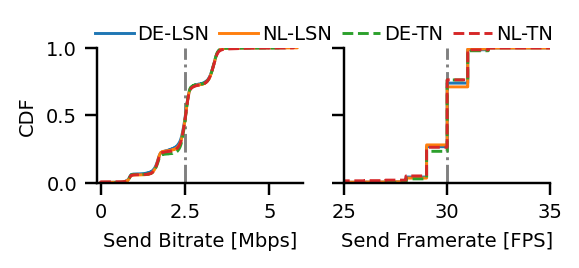

In [40]:

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(acm_column_width,1))
legend_items = ['DE', 'NL']
metrics = ["send_bitrate", "send_fps"]

labels_short = {
    "NL": "NL-LSN",
    "NO": "NO-LSN",
    "DE": "DE-LSN",
    "AQ": "AQ-LSN"
}
linestyles = ["solid", "solid"]

for color_index, location in enumerate(legend_items):
    for index, ax in enumerate(axs):
        df_tmp = df_metrics_teams_starlink[(df_metrics_teams_starlink.metric == metrics[index]) & (df_metrics_teams_starlink.location == location)]
        ax.ecdf(df_tmp["value"], label=labels_short[location], color="C"+str(color_index), ls=linestyles[color_index])


labels_short = {
    "NL": "NL-TN",
    "NO": "NO-TN",
    "DE": "DE-TN",
    "AQ": "AQ-TN"
}
linestyles = ["dashed", "dashed"]

for color_index, location in enumerate(legend_items):
    for index, ax in enumerate(axs):
        df_tmp = df_metrics_teams_terrestrial[(df_metrics_teams_terrestrial.metric == metrics[index]) & (df_metrics_teams_terrestrial.location == location)]
        ax.ecdf(df_tmp["value"], label=labels_short[location], color="C"+str(color_index+2), ls=linestyles[color_index])


titles = ["", ""]
x_labels = ["Send Bitrate [Mbps]", "Send Framerate [FPS]"]
y_labels=["CDF", ""]
target_rates = [2.5, 30]
for index, ax in enumerate(axs):
    ax.set_xlim(left=-0.1)
    ax.set_title(titles[index])
    ax.set_xlabel(x_labels[index])
    ax.set_ylabel(y_labels[index])
    ax.axvline(target_rates[index], color="gray", ls="-.", zorder=-1)
    if index != 0:
        ax.tick_params(labelleft=False)
    if index == 0:
        ax.legend(loc='center', frameon=False, handletextpad=0.2, bbox_to_anchor=(1.1,1.1), ncols=4, columnspacing=0.5)

axs[0].set_xlim(left=-.1,right=6)
axs[1].set_xlim(left=25, right=35)
axs[0].set_xticks(ticks=[0,2.5,5], labels=["0", "2.5", "5"])

plt.savefig('teams-lsn-tn.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

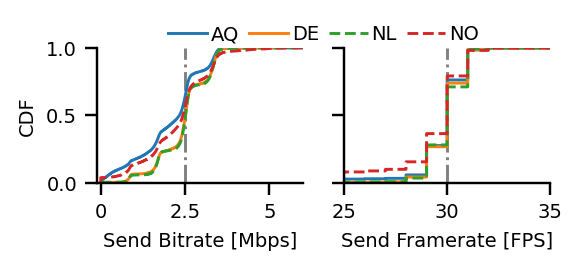

In [41]:

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(acm_column_width,1))
legend_items = ['AQ', 'DE', 'NL', 'NO']
metrics = ["send_bitrate", "send_fps"]
labels_short = {
    "NL": "NL",
    "NO": "NO",
    "DE": "DE",
    "AQ": "AQ"
}
linestyles = ["solid", "solid", "dashed", "dashed"]

for color_index, location in enumerate(legend_items):
    for index, ax in enumerate(axs):
        df_tmp = df_metrics_teams_starlink[(df_metrics_teams_starlink.metric == metrics[index]) & (df_metrics_teams_starlink.location == location)]
        ax.ecdf(df_tmp["value"], label=labels_short[location], color="C"+str(color_index), ls=linestyles[color_index])

titles = ["", ""]
x_labels = ["Send Bitrate [Mbps]", "Send Framerate [FPS]"]
y_labels=["CDF", ""]
target_rates = [2.5, 30]
for index, ax in enumerate(axs):
    ax.set_xlim(left=-0.1)
    ax.set_title(titles[index])
    ax.set_xlabel(x_labels[index])
    ax.set_ylabel(y_labels[index])
    ax.axvline(target_rates[index], color="gray", ls="-.", zorder=-1)
    if index != 0:
        ax.tick_params(labelleft=False)
    if index == 0:
        ax.legend(loc='center', frameon=False, handletextpad=0.2, bbox_to_anchor=(1.1,1.1), ncols=4, columnspacing=0.5)

axs[0].set_xlim(left=-.1,right=6)
axs[1].set_xlim(left=25, right=35)
axs[0].set_xticks(ticks=[0,2.5,5], labels=["0", "2.5", "5"])
plt.savefig('teams-geo.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [33]:
groups = [
    {"label": "AQ",  "color": "C0", "ls": "solid", "measurements": [m for f, m in measurements_teams.items() if "aq-" in f]},
    {"label": "DE",  "color": "C1", "ls": "solid", "measurements": [m for f, m in measurements_teams.items() if "de-" in f]},
    {"label": "NL",  "color": "C2", "ls": "dashed", "measurements": [m for f, m in measurements_teams.items() if "nl-" in f]},
    {"label": "NO",  "color": "C3", "ls": "dashed", "measurements": [m for f, m in measurements_teams.items() if "no-" in f]},
]

In [34]:
def get_handover_times(measurement):
        reconfig_times = []
        min_ts, max_ts = measurement.data_parquet_sender.data.index.min(), measurement.data_parquet_sender.data.index.max()
        if measurement.data_dishy_sender is not None:
            for t in measurement.data_dishy_sender.switch_timestamps:
                if t < min_ts or t > max_ts:
                    continue
                reconfig_times.append(("sender", t))
        return reconfig_times

In [35]:
def ensure_utc_index(index):
    """Make sure a DatetimeIndex is UTC."""
    return index.tz_localize("UTC") if index.tz is None else index.tz_convert("UTC")

In [36]:
def ensure_utc_timestamp(ts):
    """Make sure a single Timestamp is UTC."""
    return ts.tz_localize("UTC") if ts.tzinfo is None else ts.tz_convert("UTC")

In [ ]:
# the teams version doesnt have skip, all uses of this function must filter the first and last 30s outside of this function
def get_reconfiguration_times(measurement, exclude_handovers=False, handover_tolerance_s=1.0):
    min_ts, max_ts = measurement.data_parquet_sender.data.index.min(), measurement.data_parquet_sender.data.index.max()
    min_ts = ensure_utc_timestamp(min_ts)
    max_ts = ensure_utc_timestamp(max_ts)
    reconfig_offsets = [12, 27, 42, 57]
    current_minute = min_ts.floor("min")
    all_reconfigs = []
    while current_minute <= max_ts:
        for offset in reconfig_offsets:
            ts = current_minute + pd.Timedelta(seconds=offset)
            if min_ts <= ts <= max_ts:
                all_reconfigs.append(ts)
        current_minute += pd.Timedelta(minutes=1)

    if not exclude_handovers:
        return all_reconfigs

    handover_timestamps = [ensure_utc_timestamp(ts) for _, ts in measurement.get_handover_times()]
    return [ts for ts in all_reconfigs
            if not any(abs((ts - ho).total_seconds()) < handover_tolerance_s for ho in handover_timestamps)]

In [42]:
def get_reconfig_times_with_bitrate_drop(m, absolute_threshold=0.3, relative_threshold=0.0, window_s=1.5, skip_s=30.0):
    if m.data_parquet_sender is None or "OutboundRTP.TargetBitrate" not in m.data_parquet_sender.data:
        return []
    
    target = m.data_parquet_sender.data["OutboundRTP.TargetBitrate"].copy()
    target.index = ensure_utc_index(target.index)
    target_mbps = target / 1e6
    
    min_ts = target.index.min() + pd.Timedelta(seconds=skip_s)
    max_ts = target.index.max() - pd.Timedelta(seconds=skip_s)
    
    timestamps = get_reconfiguration_times(m)
    timestamps = [ts for ts in timestamps if ensure_utc_timestamp(ts) >= min_ts and ensure_utc_timestamp(ts) <= max_ts]
    
    drop_reconfigs = []
    for ts in timestamps:
        ts = ensure_utc_timestamp(ts)
        pre  = target_mbps.loc[ts - pd.Timedelta(seconds=window_s):ts].max()
        post = target_mbps.loc[ts:ts + pd.Timedelta(seconds=window_s)].min()
    
        if pd.isna(pre) or pd.isna(post) or pre <= 0:
            continue
    
        absolute_drop = pre - post
        relative_drop = absolute_drop / pre
        if absolute_threshold == 0 and relative_threshold > 0:
            if relative_drop > relative_threshold:
                drop_reconfigs.append(ensure_utc_timestamp(ts))
        elif relative_threshold == 0 and absolute_threshold > 0:
            if absolute_drop > absolute_threshold:
                drop_reconfigs.append(ensure_utc_timestamp(ts))
        else:
            if (absolute_drop > absolute_threshold) & (relative_drop > relative_threshold):
                drop_reconfigs.append(ensure_utc_timestamp(ts))
    
    
    return drop_reconfigs

In [49]:

for g in groups:
    total_seconds = 0
    below_target_seconds = 0
    drop_below_seconds = 0
    total_drops = 0
    
    relative_threshold = 0.15
    window_s = 1.5
    skip_s = 30.0
    fixed_threshold = 2.5 * (1 - relative_threshold)
    
    for m in g["measurements"]:
        if m.data_parquet_sender is None or "OutboundRTP.TargetBitrate" not in m.data_parquet_sender.data:
            continue
        
        target = m.data_parquet_sender.data["OutboundRTP.TargetBitrate"].copy()
        target.index = ensure_utc_index(target.index)
        target_mbps = target / 1e6
        
        skip_start = target_mbps.index.min() + pd.Timedelta(seconds=skip_s)
        skip_end = target_mbps.index.max() - pd.Timedelta(seconds=skip_s)
        target_mbps = target_mbps.loc[skip_start:skip_end]
        if target_mbps.empty:
            continue
        
        dt = target_mbps.index.to_series().diff().dt.total_seconds().fillna(0)
        total_seconds += dt.sum()
        below_target_seconds += dt[target_mbps < fixed_threshold].sum()
        
        timestamps = [ensure_utc_timestamp(ts) for ts in get_reconfiguration_times(m)
                      if skip_start <= ensure_utc_timestamp(ts) <= skip_end]
        
        counted = set()
        for ts in timestamps:
            pre = target_mbps.loc[ts - pd.Timedelta(seconds=window_s):ts].max()
            post = target_mbps.loc[ts:ts + pd.Timedelta(seconds=window_s)].min()
            
            if pd.isna(pre) or pd.isna(post) or pre <= 0:
                continue
            
            relative_drop = (pre - post) / pre
            if relative_drop > relative_threshold:
                total_drops += 1
                
                remaining = target_mbps.loc[ts:]
                recovered = remaining >= fixed_threshold
                if recovered.any():
                    end = recovered.index[recovered][0]
                else:
                    end = remaining.index[-1]
                
                window = target_mbps.loc[ts:end]
                window_dt = window.index.to_series().diff().dt.total_seconds().fillna(0)
                for idx_ts, val, interval in zip(window.index, window.values, window_dt.values):
                    if val < fixed_threshold and idx_ts not in counted:
                        drop_below_seconds += interval
                        counted.add(idx_ts)
    
    if total_seconds > 0:
        print(g['label'])
        print(f"  Total:              {total_seconds:.0f}s")
        print(f"  Below threshold:    {below_target_seconds:.1f}s ({100 * below_target_seconds / total_seconds:.1f}%)")
        print(f"  Detected drops:     {total_drops}")
        print(f"  Attributed:         {drop_below_seconds:.1f}s ({100 * drop_below_seconds / total_seconds:.1f}%)")
        if below_target_seconds > 0:
            print(f"  Attribution:        {100 * drop_below_seconds / below_target_seconds:.1f}%")
        print()

AQ
  Total:              16781s
  Below threshold:    5519.2s (32.9%)
  Detected drops:     123
  Attributed:         2553.5s (15.2%)
  Attribution:        46.3%

DE
  Total:              28534s
  Below threshold:    1237.5s (4.3%)
  Detected drops:     106
  Attributed:         61.0s (0.2%)
  Attribution:        4.9%

NL
  Total:              27667s
  Below threshold:    460.0s (1.7%)
  Detected drops:     39
  Attributed:         25.1s (0.1%)
  Attribution:        5.5%

NO
  Total:              19300s
  Below threshold:    4543.2s (23.5%)
  Detected drops:     345
  Attributed:         1455.5s (7.5%)
  Attribution:        32.0%



In [45]:
def get_javascript_target_bitrate_series(measurement: Measurement) -> pd.Series | None:
    if measurement.data_parquet_sender is not None:
        if "OutboundRTP.TargetBitrate" in measurement.data_parquet_sender.data:
            bitrate_series = measurement.data_parquet_sender.data["OutboundRTP.TargetBitrate"]
            if bitrate_series.dropna().empty:
                return None
            bitrate_series = bitrate_series/1000/1000
            bitrate_series.index.name = 'Timestamp'
            bitrate_series.name = "bitrate"
            return bitrate_series
    return None

In [46]:
def median_ci_df(df, cl=0.95, n_resamples=1000):
    res = bootstrap(
        (df.to_numpy(),),
        lambda x, axis: np.nanmedian(x, axis=axis),
        axis=1,                       # epochs are the columns
        confidence_level=cl,
        n_resamples=n_resamples,
        method="percentile",
    )
    return (df.median(axis=1),
            pd.Series(res.confidence_interval.low,  index=df.index),
            pd.Series(res.confidence_interval.high, index=df.index))

In [47]:
# this function basically slices a dataframe into segments around certain events and resamples all the data so that the time resolution within a segment matches across measurements
def epoch_df(measurements, get_times, before_s, after_s, *,
             column, kind="counter", scale=1.0, side="sender", step_ms=100):
    step   = pd.Timedelta(milliseconds=step_ms)
    lo, hi = pd.Timedelta(seconds=before_s), pd.Timedelta(seconds=after_s)
    grid   = pd.timedelta_range(-lo, hi, freq=step)
    step_s = step_ms / 1000

    cols = []
    for m in measurements:
        data = getattr(m, f"data_parquet_{side}")
        if data is None or column not in data.data:
            continue
        s = data.data[column].dropna()
        if len(s) < 2:
            continue

        events = get_times(m)
        if not events:
            continue

        # Resample aligned to the first event and not to msm start
        first = ensure_utc_timestamp(events[0])
        if kind == "counter":
            r = s.resample(step, origin=first).max().diff().where(lambda x: x >= 0) / step_s * scale
        else:
            r = s.resample(step, origin=first).mean() * scale

        # Slice per event, the above alignment guarantees that the bins between measurements are aligned
        for t0 in events:
            t0 = ensure_utc_timestamp(t0)
            seg = r.loc[t0 - lo : t0 + hi]
            if len(seg) < 2:
                continue
            seg = seg.copy()
            seg.index = seg.index - t0
            cols.append(seg.reindex(grid))

    return pd.concat(cols, axis=1) if cols else None

AQ percentile of 2.125 Mbps:
0.3493855364984775
[2.250506   2.256018   2.256018   2.255579   2.2503495  2.2545345
 2.256721   2.2589075  2.2589075  2.2589075  2.265695   2.2624605
 2.259226   2.261587   2.243975   2.26109575 2.264      2.260252
 2.234661   2.2267165  2.256824   2.279919   2.2902735  2.2807205
 2.277586   2.282563   2.2866565  2.277586   2.2605615  2.235517
 2.248684   2.2726535  2.2748735  2.27396425 2.288898   2.2661135
 2.289824   2.263366   2.2642015  2.266947   2.24951075 2.2611155
 2.242434   2.242434   2.2236445  2.2236445  2.2262925  2.210837
 2.213087   2.2175515  2.2175515  2.2312265  2.2299955  2.2524615
 2.2277     2.228111   2.263134   2.166507   2.068609   1.945944
 1.8598625  1.810202   1.683018   1.600256   1.50066475 1.495024
 1.4980635  1.491702   1.4746425  1.4641425  1.4746775  1.41588175
 1.4675     1.502178   1.502178   1.425      1.421667   1.422917
 1.422917   1.4325     1.4416665  1.4925     1.53375    1.537185
 1.5135085  1.429167   1.48544    

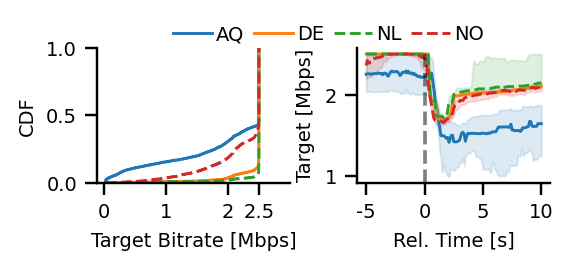

In [ ]:
# segment/epoch config in seconds
WINDOW_BEFORE = 5
WINDOW_AFTER = 10
GRID_STEP = 0.1

#drop detection config
relative_threshold = 0.15
window_s = 1.5
skip_s = 30.0
absolute_threshold=0
relative_threshold=0.15

fig, (ax_cdf, ax_target) = plt.subplots(1, 2, figsize=(acm_column_width, 1))

for g in groups:
    # Left: CDF of target bitrate
    all_values = []
    for m in g["measurements"]:
        s = get_javascript_target_bitrate_series(m)
        if s is not None:
            all_values.extend(s.dropna().values)
    if all_values:
        print(g["label"]+" percentile of 2.125 Mbps:")
        print((pd.Series(all_values) < 2.125).mean())
        ax_cdf.ecdf(all_values, color=g["color"], label=g["label"], ls=g["ls"])

    # Right: target bitrate around bitrate-drop reconfigurations
    TARGET_MBPS= dict(column="OutboundRTP.TargetBitrate", kind="value", side="sender", step_ms=GRID_STEP*1000, scale=1e-6)
    df = epoch_df(g["measurements"], lambda m: get_reconfig_times_with_bitrate_drop(m, absolute_threshold=absolute_threshold,
                                                       relative_threshold=relative_threshold,
                                                       window_s=window_s, skip_s=skip_s,), WINDOW_BEFORE, WINDOW_AFTER, **TARGET_MBPS)
    median, ci_lo, ci_hi = median_ci_df(df)
    print(median.values)
    print(pd.Series(median).max()-pd.Series(median).min()) # print the drop basically
    t = median.index.total_seconds()
    ax_target.plot(t, median.values, color=g["color"], ls=g["ls"])
    ax_target.fill_between(t, ci_lo.values, ci_hi.values, color=g["color"], alpha=0.15)

ax_cdf.set_xlabel("Target Bitrate [Mbps]")
ax_cdf.set_ylabel("CDF")
ax_cdf.legend(loc='center', frameon=False, handletextpad=0.2, bbox_to_anchor=(1.2,1.1), ncols=4, columnspacing=0.5)
ax_cdf.set_xlim(left=-.1,right=3)
ax_cdf.set_xticks(ticks=[0,1,2,2.5], labels=["0", "1", "2", "2.5"])
ax_target.axvline(0, color="black", linewidth=1.5, alpha=0.5, linestyle="--")
ax_target.set_xlabel("Rel. Time [s]")
ax_target.set_ylabel("Target [Mbps]")
ax_target.set_xticks([-5,0,5,10], labels=["-5", "0", "5", "10"])

fig.subplots_adjust(wspace=0.35)
plt.savefig('teams-target-rate-drops.pdf', bbox_inches='tight', pad_inches=0)
plt.show()